In [1]:
## Part 1: Result visualization

In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from pathlib import Path
import pandas as pd
import seaborn as sns

In [3]:
# --- Path setup ---
project_root = Path("/home/jovyan/project-WaterDig")

# Results data files
data_dir = project_root / "model_data" / "mann_kendall"

# Output directory
visualization_dir = project_root / "figures"
visualization_dir.mkdir(exist_ok=True)

print("Reading results data:", data_dir)
print("Visualization will be saved to:", visualization_dir)

Reading results data: /home/jovyan/project-WaterDig/model_data/mann_kendall
Visualization will be saved to: /home/jovyan/project-WaterDig/figures


In [4]:
#--- Read results data ---
monthly_trends = pd.read_csv(data_dir / "monthly_trends.csv")
seasonal_trends = pd.read_csv(data_dir / "seasonal_trends.csv")
yearly_trends  = pd.read_csv(data_dir / "yearly_trends.csv")

In [5]:
# Part 1.1: Monthly results visualization

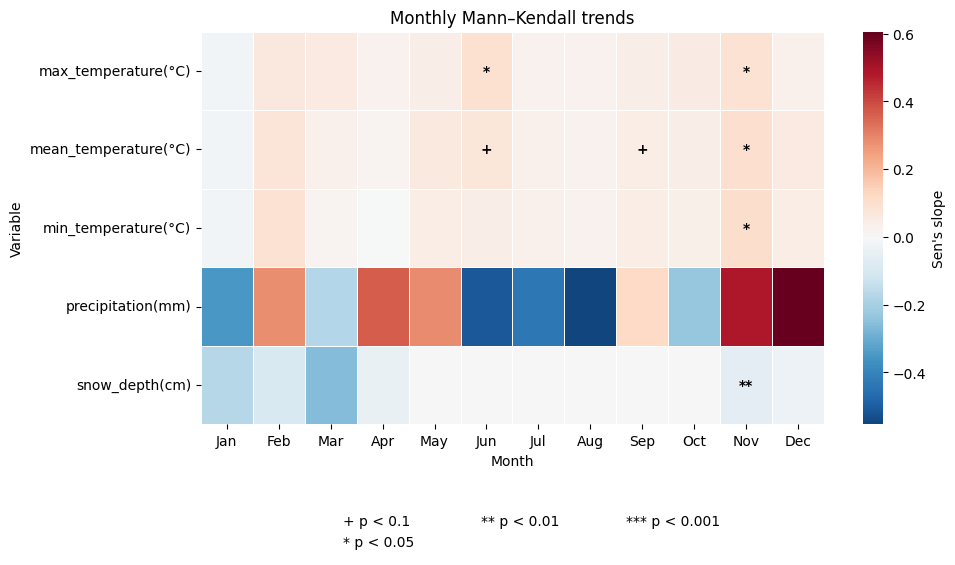

In [6]:
# --- Month labels ---
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

# Add month names
monthly_trends["month_name"] = monthly_trends["month"].apply(lambda x: month_labels[x-1])

# --- Pivot Sen slope ---
heatmap_data = monthly_trends.pivot(index="variable", columns="month_name", values="sen_slope")
heatmap_data = heatmap_data[month_labels]

# --- Significance symbols ---
def get_significance_symbol(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "+"
    else:
        return ""

monthly_trends["sig"] = monthly_trends["p_value"].apply(get_significance_symbol)

sig_data = monthly_trends.pivot(index="variable", columns="month_name", values="sig")
sig_data = sig_data[month_labels]

fig, ax = plt.subplots(figsize=(10, 6))

# Heatmap
sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Sen's slope"},
    ax=ax
)

# --- Add significance symbols ---
for i in range(sig_data.shape[0]):
    for j in range(sig_data.shape[1]):
        sig = sig_data.iloc[i, j]
        if sig != "":
            ax.text(
                j + 0.5,
                i + 0.5,
                sig,
                ha='center',
                va='center',
                color='black',
                fontsize=10,
                fontweight='bold'
            )

# Labels
ax.set_title("Monthly Mann–Kendall trends")
ax.set_xlabel("Month")
ax.set_ylabel("Variable")

# --- Legend ---
legend_elements = [
    Line2D([0], [0], color='w', label='+ p < 0.1'),
    Line2D([0], [0], color='w', label='* p < 0.05'),
    Line2D([0], [0], color='w', label='** p < 0.01'),
    Line2D([0], [0], color='w', label='*** p < 0.001')
]

ax.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.35),
    ncol=3,
    frameon=False
)

plt.tight_layout()

# --- Save figure ---
fig.savefig(
    visualization_dir / "Fig.1: Monthly_MK_trends.png",   
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [7]:
# Fig.1: Monthly Mann–Kendall trends shown as a heatmap of Sen’s slope values for each variable. Positive (red) values indicate increasing trends and negative (blue) values indicate decreasing trends. Significance levels are denoted as + (p < 0.1), * (p < 0.05), ** (p < 0.01), and *** (p < 0.001).

In [8]:
# Part 1.2: Seasonal results visualization

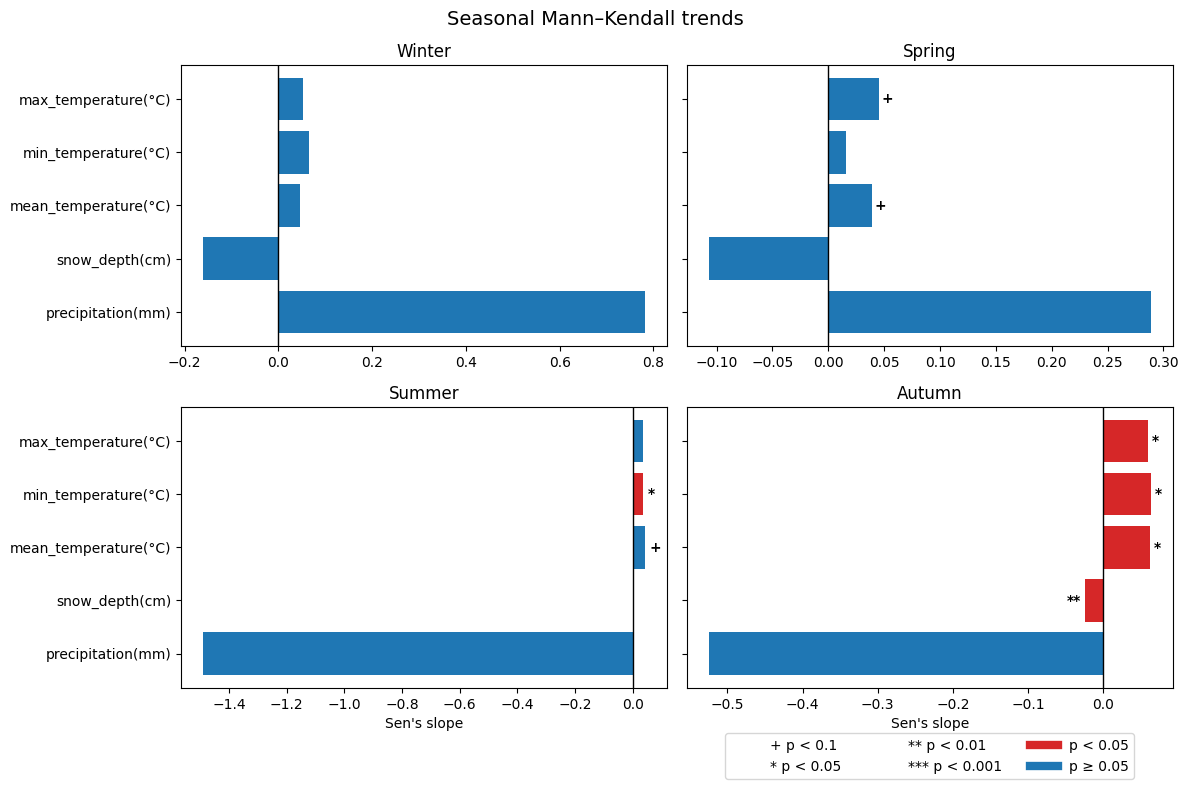

In [9]:
season_order = ["Winter", "Spring", "Summer", "Autumn"]

# --- Significance symbols ---
def get_significance_symbol(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "+"
    else:
        return ""

# --- Color mapping ---
def get_color(p):
    return "#d62728" if p < 0.05 else "#1f77b4"

variables = seasonal_trends["variable"].unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for i, season in enumerate(season_order):
    ax = axes[i]

    df_season = seasonal_trends[seasonal_trends["season"] == season].copy()
    df_season = df_season.set_index("variable").loc[variables]

    df_season["sig"] = df_season["p_value"].apply(get_significance_symbol)
    colors = df_season["p_value"].apply(get_color)

    y = np.arange(len(variables))

    ax.barh(y, df_season["sen_slope"], color=colors)

    # Zero line
    ax.axvline(0, color='black', linewidth=1)

    # Labels
    ax.set_title(season)
    ax.set_yticks(y)
    ax.set_yticklabels(variables)
    ax.invert_yaxis()

    # Add significance symbols
    offset = max(abs(df_season["sen_slope"])) * 0.01

    for j, (slope, sig) in enumerate(zip(df_season["sen_slope"], df_season["sig"])):
        if sig != "":
            x_pos = slope + offset if slope > 0 else slope - offset

            ax.text(
                x_pos,
                j,
                sig,
                va='center',
                ha='left' if slope > 0 else 'right',
                fontsize=10,
                fontweight='bold'
            )

# Labels
fig.suptitle("Seasonal Mann–Kendall trends", fontsize=14)
axes[2].set_xlabel("Sen's slope")
axes[3].set_xlabel("Sen's slope")

legend_elements = [
    Line2D([0], [0], color='w', label='+ p < 0.1'),
    Line2D([0], [0], color='w', label='* p < 0.05'),
    Line2D([0], [0], color='w', label='** p < 0.01'),
    Line2D([0], [0], color='w', label='*** p < 0.001'),
    Line2D([0], [0], color='#d62728', lw=6, label='p < 0.05'),
    Line2D([0], [0], color='#1f77b4', lw=6, label='p ≥ 0.05')
]

ax.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.35),
    ncol=3
)
plt.tight_layout()

plt.show()



In [10]:
# Fig.2: Seasonal Mann–Kendall trends for the analyzed variables, shown separately for winter, spring, summer, and autumn. Horizontal bars represent Sen’s slope values for each variable. Positive slopes indicate increasing trends and negative slopes indicate decreasing trends. Red bars indicate statistically significant trends (p < 0.05), while blue bars indicate non-significant trends. Significance levels are denoted as + (p < 0.1), * (p < 0.05), ** (p < 0.01), and *** (p < 0.001).

In [11]:
df_season=fig.savefig(
    visualization_dir / "Fig.2: Seasonal_MK_trends.png",
    dpi=300,
    bbox_inches="tight"
)

In [12]:
# Part 1.3: Yearly results visualization

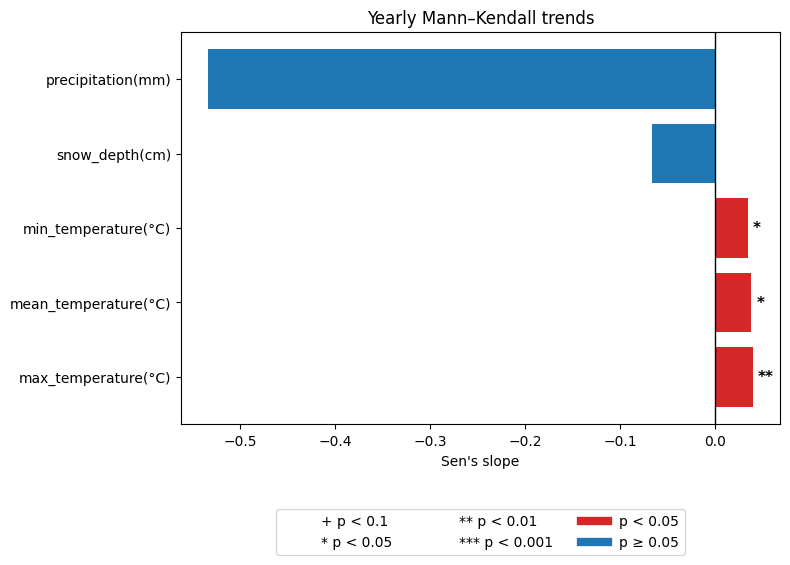

In [13]:
# Sort variables 
yearly_plot = yearly_trends.sort_values("sen_slope").reset_index(drop=True)

# --- Significance symbols ---
def get_significance_symbol(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "+"
    else:
        return ""

yearly_plot["sig"] = yearly_plot["p_value"].apply(get_significance_symbol)

# --- Color mapping ---
def get_color(p):
    return "#d62728" if p < 0.05 else "#1f77b4"

colors = yearly_plot["p_value"].apply(get_color)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

y = np.arange(len(yearly_plot))

ax.barh(y, yearly_plot["sen_slope"], color=colors)

# Zero line
ax.axvline(0, color='black', linewidth=1)

# Labels
ax.set_yticks(y)
ax.set_yticklabels(yearly_plot["variable"])
ax.invert_yaxis()

ax.set_xlabel("Sen's slope")
ax.set_title("Yearly Mann–Kendall trends")

# --- Add significance symbols ---
offset = max(abs(yearly_plot["sen_slope"])) * 0.01

for i, (slope, sig) in enumerate(zip(yearly_plot["sen_slope"], yearly_plot["sig"])):
    if sig != "":
        x_pos = slope + offset if slope > 0 else slope - offset

        ax.text(
            x_pos,
            i,
            sig,
            va='center',
            ha='left' if slope > 0 else 'right',
            fontsize=11,
            fontweight='bold'
        )

legend_elements = [
    Line2D([0], [0], color='w', label='+ p < 0.1'),
    Line2D([0], [0], color='w', label='* p < 0.05'),
    Line2D([0], [0], color='w', label='** p < 0.01'),
    Line2D([0], [0], color='w', label='*** p < 0.001'),
    Line2D([0], [0], color='#d62728', lw=6, label='p < 0.05'),
    Line2D([0], [0], color='#1f77b4', lw=6, label='p ≥ 0.05')
]

ax.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.35),
    ncol=3
)
plt.tight_layout()
plt.show()

In [14]:
# Fig.3: Yearly Mann–Kendall trends for the analyzed variables. Horizontal bars represent Sen’s slope values based on annual time series. Positive values indicate increasing trends and negative values indicate decreasing trends. Red bars correspond to statistically significant trends (p < 0.05), while blue bars indicate non-significant trends. Significance levels are shown as + (p < 0.1), * (p < 0.05), ** (p < 0.01), and *** (p < 0.001

In [15]:
yearly_plot=fig.savefig(
    visualization_dir / "Fig.3: Yearly_MK_trends.png",
    dpi=300,
    bbox_inches="tight"
)